# Ajuste de taxas de transfência não radiativa 

O sistema de EDO que contém os parâmetros de interesse é

\begin{equation}
\begin{aligned}
    \frac{dn_5}{dt}
    &=
    \sigma P F(t)\, n_4
    - W_{51} n_1 n_5
    - W_{52} n_2 n_5
    - k_{54} n_5 
    \\
    \frac{dn_2}{dt}
    &=
    W_{51} n_1 n_5
    - W_{52} n_2 n_5
    - k_{21} n_2 
    \\
    \frac{dn_3}{dt}
    &=
    W_{52} n_2 n_5
    - k_{31} n_3 
\end{aligned}
\end{equation}

Adimensionalizando a concentração por $n_1$ e o tempo por $2\pi/\omega = 1/f$, obtemos

\begin{aligned}
\frac{dx_5}{d\tau}
&=
\Pi F(\tau) x_4
- W'_{51} x_5
- W'_{52} x_2 x_5
- k'_{54} x_5
\\
\frac{dx_2}{d\tau}
&=
W'_{51} x_5
- W'_{52} x_2 x_5
- k'_{21} x_2
\\
\frac{dx_3}{d\tau}
&=
W'_{52} x_2 x_5
- k'_{31} x_3
\end{aligned},
onde 

### Dados experimentais

In [15]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares, curve_fit
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from treament_tcspc_data import fetch_data_filenames, extract_data_info_from_path, time_domain_visual_verification
# from snr_aux_functions import get_snr_db, plot_time_and_freq_domain

In [16]:
pd_list = np.load("phase_difference_list.npy") #obtained from https://github.com/habakukc22/many-particles-analysis-more-repetitions

In [17]:
pd_list.shape

(30, 26, 3)

(30, 26, 3)


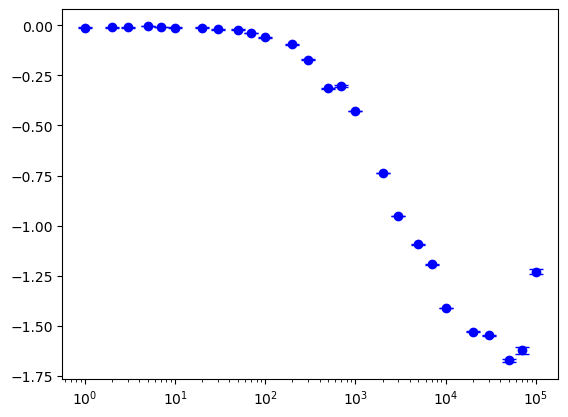

In [18]:
print(pd_list.shape)

for p_idx, p in enumerate(pd_list):
    if p_idx != 0: continue
    for step in p:
        # print(point)
        plt.errorbar(
            step[0], 
            step[1],
            yerr=step[2],
            fmt="o",
            capsize=5,
            color="blue"
            )
plt.xscale("log")
plt.show()

### Tentativa de parâmetros iniciais via eq. 18

In [19]:
#--------------------------------------
# Estimativa de n1 e n4
#--------------------------------------
dens_y2o3 = 5.010 #g/cm^3
massa_molar_y2o3 = 225.81 #g/mol
frac_er = 0.005 # percentual de Er3+ da amostra no experimento
frac_yb = 0.015 # percentual de Yb3+ da amostra no experimento

n1 = (dens_y2o3/massa_molar_y2o3)*(6.022e23)*2*(frac_er)
n4 = (dens_y2o3/massa_molar_y2o3)*(6.022e23)*2*(frac_yb)

In [20]:
#--------------------------------------
# Parâmetros inseridos
#--------------------------------------
k21 = 16.66   # Tab. 2 em https://doi.org/10.1063/1.2739301
k54 = 1279.0  # Tab. 2 Lu0 em https://doi.org/10.1016/j.jallcom.2021.159227
sigma = 1.75e-20 # # Supporting Information, page S5, Labrador

P = 1e25    # from measurements
# P = 5.4e20    # fótons / (cm^2 * s) (baseado em 110 W/cm^2 do paper de Labrador)

#====================================================
# Constantes depois do ajuste de eq. 18
#====================================================
k31 = 17237.7 # s^-1
ww51 = 1e-10#8.192933479247868e-09 # chute incial
ww52 = 1e-10#1.9970817793515877e-07 # chute inicial
#====================================================

#====================================================
# Dados de meus experimentos
#====================================================
amplitude = 0.5
offset = 0.5
#====================================================

num_points = 23 

In [21]:
# 3. Função para Extrair a Fase via FFT
def extrair_fase(t, n3, freq):
    # DICA CRUCIAL: Descartar a primeira metade da simulação (o transiente)
    # Analisamos apenas a parte onde a onda já estabilizou
    meio = len(t) // 2
    t_estavel = t[meio:]
    n3_estavel = n3[meio:]
    
    # Recria o sinal do laser no mesmo intervalo de tempo para comparação
    laser_estavel = offset + amplitude * np.cos(2 * np.pi * freq * t_estavel)
    
    N = len(t_estavel)
    dt = t_estavel[1] - t_estavel[0]
    
    # Aplica a FFT
    yf_n3 = fft(n3_estavel)
    yf_laser = fft(laser_estavel)
    xf = fftfreq(N, dt)
    
    # Encontra o índice da frequência de modulação (freq) no array da FFT
    idx = np.argmin(np.abs(xf - freq))
    
    # Extrai o ângulo (fase) de ambos os sinais nesse pico de frequência
    fase_n3 = np.angle(yf_n3[idx])
    fase_laser = np.angle(yf_laser[idx])
    
    # Diferença de fase (Luminescência - Laser)
    delta_fase = fase_n3 - fase_laser
    
    # Garante que o valor fique no intervalo correto [-pi, pi]
    delta_fase = np.angle(np.exp(1j * delta_fase))
    
    return delta_fase

def adj_ph(x):
    return (180/np.pi)*np.abs(x)

# Ajustando novos parâmetros
wp51 = lambda f, W51: W51*n1/f
wp52 = lambda f, W52: W52*n1/f
kp21 = lambda f: k21/f
kp31 = lambda f: k31/f
kp45 = lambda f: sigma*P/f
kp54 = lambda f: k54/f
x4 = n4/n1


### Ajuste numérico

In [22]:
# initial_values = [[1e-18,1e-18], [1e-19,1e-19], [1e-20,1e-20], [1e-21,1e-21]]

In [23]:
# =====================================================================
# 4. Função Residual para o Otimizador
# =====================================================================
def odes(t, x, W51, W52, freq):
    # O 't' aqui representa a variável adimensional tau (tau = t*f)
    x5, x2, x3 = x

    # Função do laser conforme os parâmetros definidos anteriormente
    F_t = offset + amplitude * np.cos(2 * np.pi * t)

    # Prevenção numérica: a intensidade não pode ser negativa
    if F_t < 0: F_t = 0.0 
        
    dx5_dt = kp45(freq) * F_t * x4 - wp51(freq, W51) * x5 - wp52(freq, W52) * x2 * x5 - kp54(freq) * x5
    dx2_dt = wp51(freq, W51) * x5 - wp52(freq, W52) * x2 * x5 - kp21(freq) * x2
    dx3_dt = wp52(freq, W52) * x2 * x5 - kp31(freq) * x3
    
    return [dx5_dt, dx2_dt, dx3_dt]

def funcao_custo(parametros, freq_exp, fase_exp):
    W51, W52 = parametros
    fases_calculadas = []
    
    for f in freq_exp:
        # Simula 200 ciclos em tempo adimensional para garantir que o transiente morra
        t_span = (0, 200) 
        t_eval = np.linspace(t_span[0], t_span[1], 10000)
        
        sol = solve_ivp(
            odes, 
            t_span, 
            [0, 0, 0], 
            t_eval=t_eval,
            args=(W51, W52, f), 
            method='Radau' # Mantendo o método Radau que demonstrou estabilidade acima
        )
        
        # Converte de volta para unidades físicas antes de extrair a fase
        n3 = (sol.y[2]) * n1 
        ts = (sol.t) * (1/f) 
        
        fase_calc = extrair_fase(ts, n3, f)
        fases_calculadas.append(fase_calc)
        
    fases_calculadas = np.array(fases_calculadas)
    
    # O Least Squares minimizará a diferença entre os arrays
    return fases_calculadas - fase_exp


In [ ]:
# =====================================================================
# 5. EXECUÇÃO DO AJUSTE
# =====================================================================
# Limitando ao número de pontos que foram simulados na célula anterior

# lista para armazenar as taxas w51 e w52 ajustadas para cada partícula 
w_list = []

for chute_inicial in initial_values:

    for p_id, pd in enumerate(pd_list):
        if p_id != 0: continue
        frequencias_experimentais = pd[:num_points, 0] 
        fases_experimentais = pd[:num_points, 1] 

        # Palpite inicial para W51 e W52 (em cm^3 / s)
        # chute_inicial = [ww51, ww52]
        
        print("-" * 30)
        print(f"Iniciando ajuste numérico para a partícula {p_id + 1}. Isso pode levar alguns minutos...")
        print(f"Chute inicial: {chute_inicial}")

        # Roda o otimizador
        resultado = least_squares(
            funcao_custo, 
            chute_inicial, 
            args=(frequencias_experimentais, fases_experimentais),
            bounds=(0, np.inf), # Força valores estritamente positivos de forma nativa
            method='trf',
            x_scale='jac' # Fundamental: compensa a diferença de ordens de grandeza (ex: 1e-9 vs 1e-7)
        )

        w_list.append([resultado.x[0], resultado.x[1], resultado.cost])

        print("AJUSTE CONCLUÍDO!")
        print(f"W51 encontrado = {resultado.x[0]:.3e} cm³/s")
        print(f"W52 encontrado = {resultado.x[1]:.3e} cm³/s")
        print(f"custo = {resultado.cost:.4e} ")
        print("-" * 30)

In [ ]:
# w_list = np.array(w_list)

# np.save("w_list", w_list)

#### Plots

In [24]:
init_val_res = np.loadtxt("test.csv", delimiter=",", skiprows=1)

print(init_val_res)

[[1.0000e-08 1.0670e-08 1.0610e-08 4.2841e-02]
 [1.0000e-09 2.0550e-07 5.7570e-10 4.1331e-02]
 [1.0000e-10 3.8200e-08 1.0000e-10 4.1620e-02]
 [1.0000e-11 3.8200e-08 1.0000e-10 4.1620e-02]
 [1.0000e-12 3.8200e-08 1.0000e-10 4.1620e-02]
 [1.0000e-13 3.8200e-08 1.0000e-10 4.1620e-02]
 [1.0000e-14 3.8200e-08 1.0000e-10 4.1620e-02]
 [1.0000e-15 3.8200e-08 1.0000e-10 4.1620e-02]
 [1.0000e-16 3.8200e-08 1.0000e-10 4.1620e-02]
 [1.0000e-17 3.8200e-08 1.0000e-10 4.1620e-02]
 [1.0000e-18 3.8200e-08 1.0000e-10 4.1620e-02]
 [1.0000e-19 3.8200e-08 1.0000e-10 4.1620e-02]
 [1.0000e-20 3.8200e-08 1.0000e-10 4.1620e-02]
 [1.0000e-21 3.8200e-08 1.0000e-10 4.1620e-02]]


In [25]:
init_val_res[0][2]

np.float64(1.061e-08)

1.067e-08 1.061e-08
chute inicial = 1e-08, custo = 0.042841


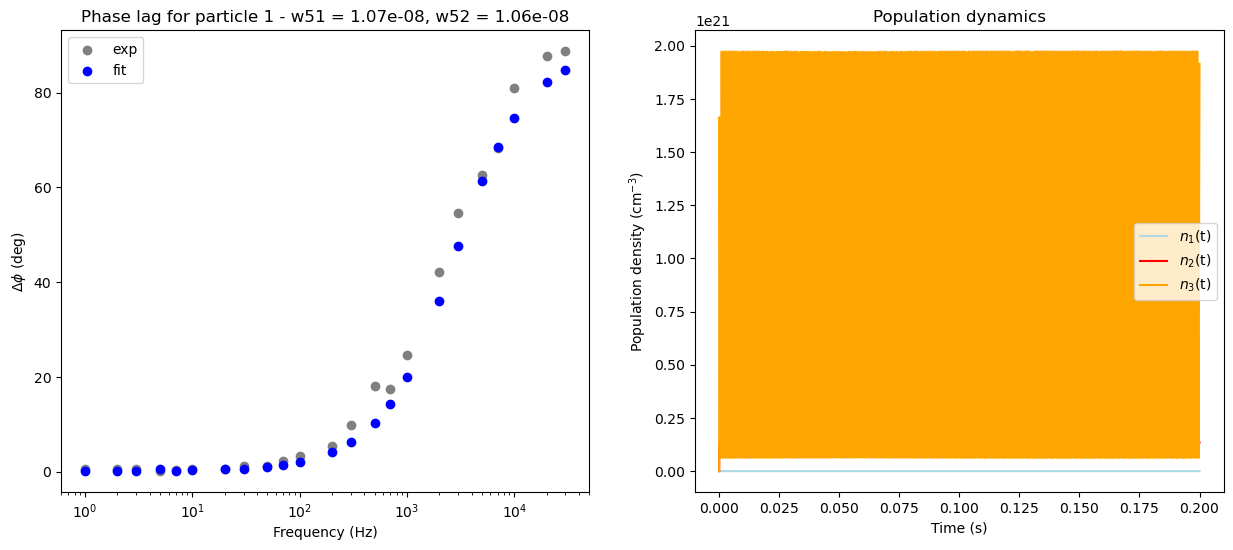

2.055e-07 5.757e-10
chute inicial = 1e-09, custo = 0.041331


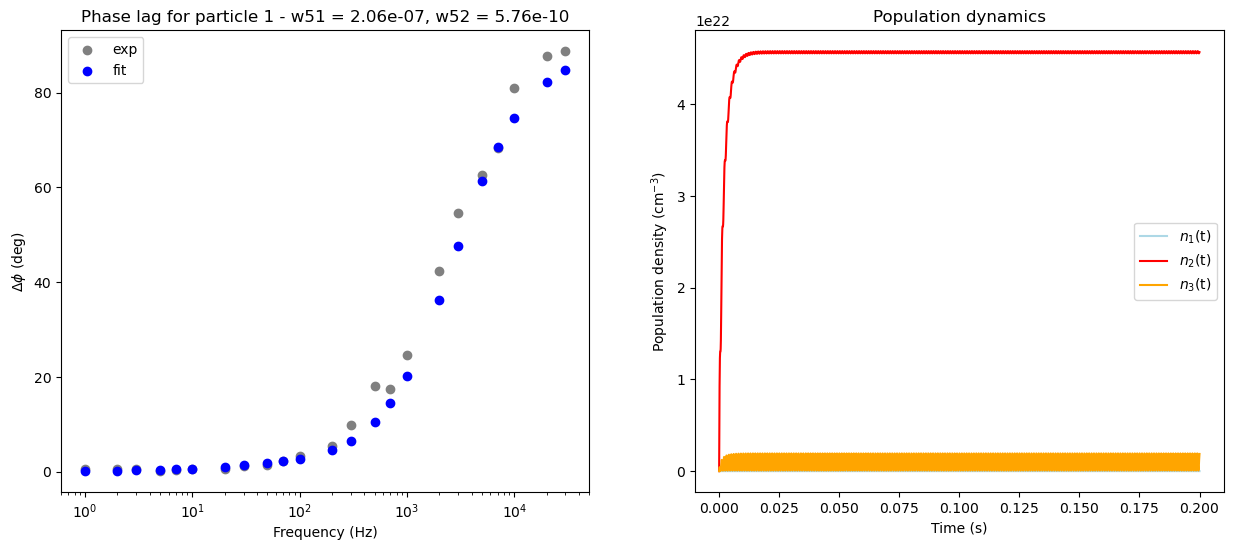

3.82e-08 1e-10
chute inicial = 1e-10, custo = 0.04162


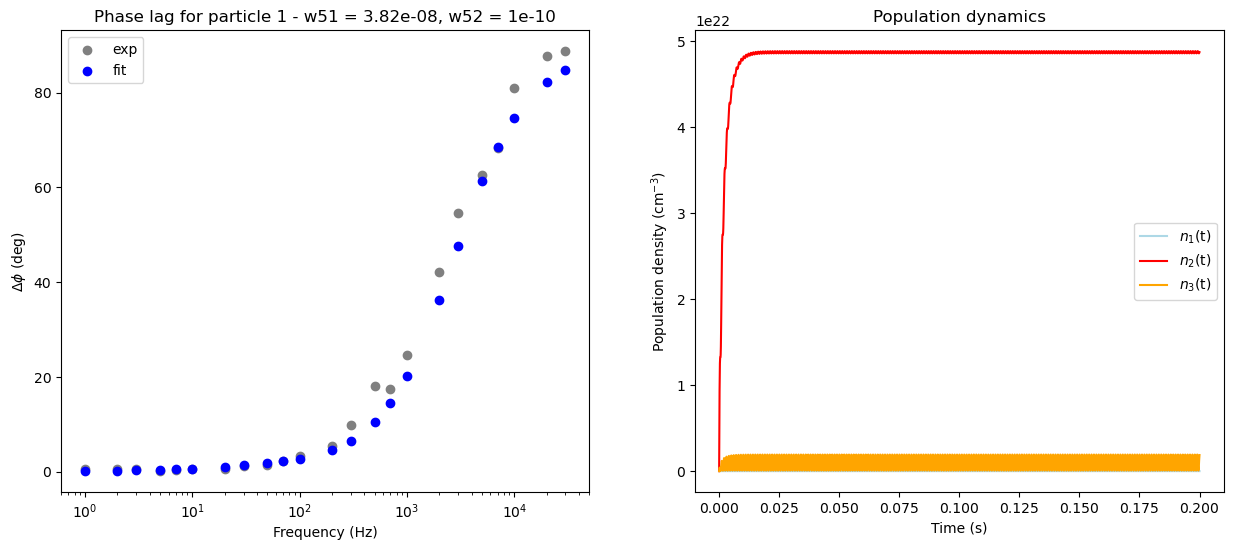

3.82e-08 1e-10
chute inicial = 1e-11, custo = 0.04162


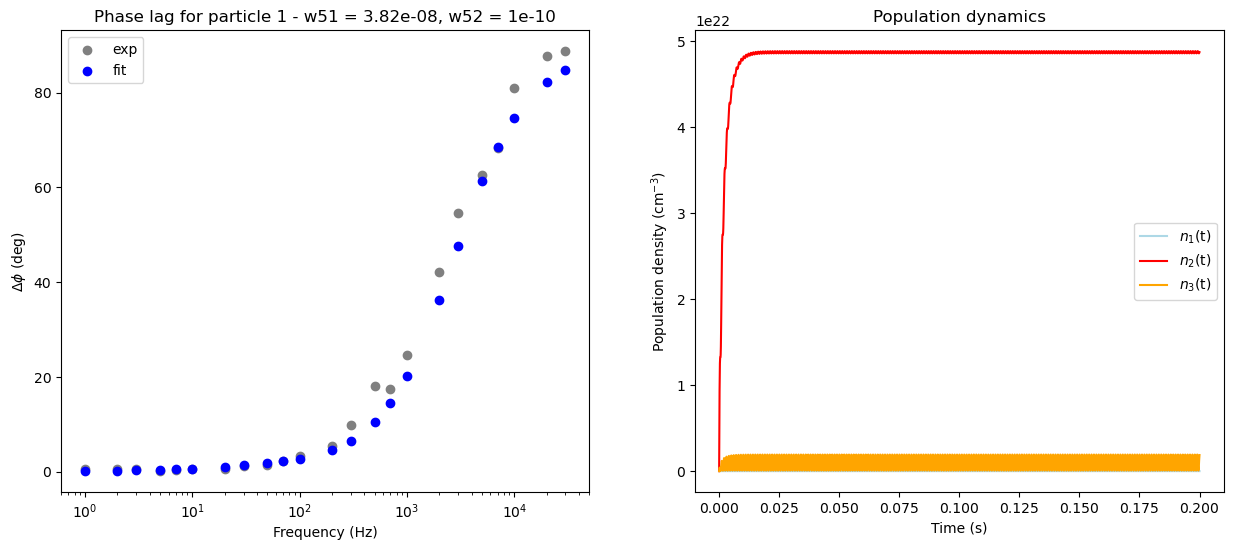

3.82e-08 1e-10
chute inicial = 1e-12, custo = 0.04162


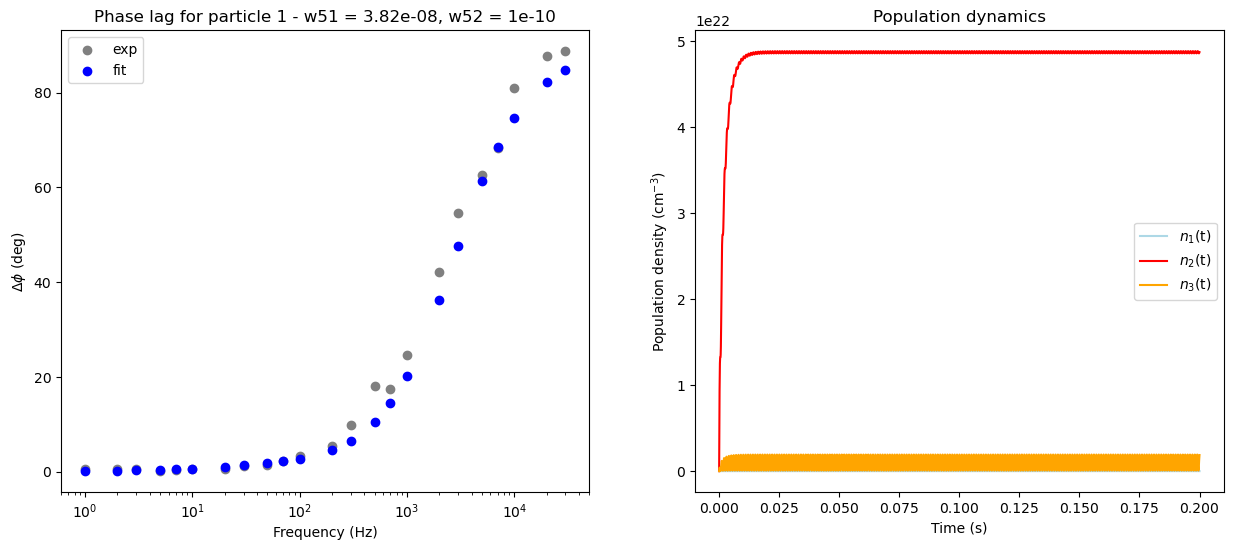

3.82e-08 1e-10
chute inicial = 1e-13, custo = 0.04162


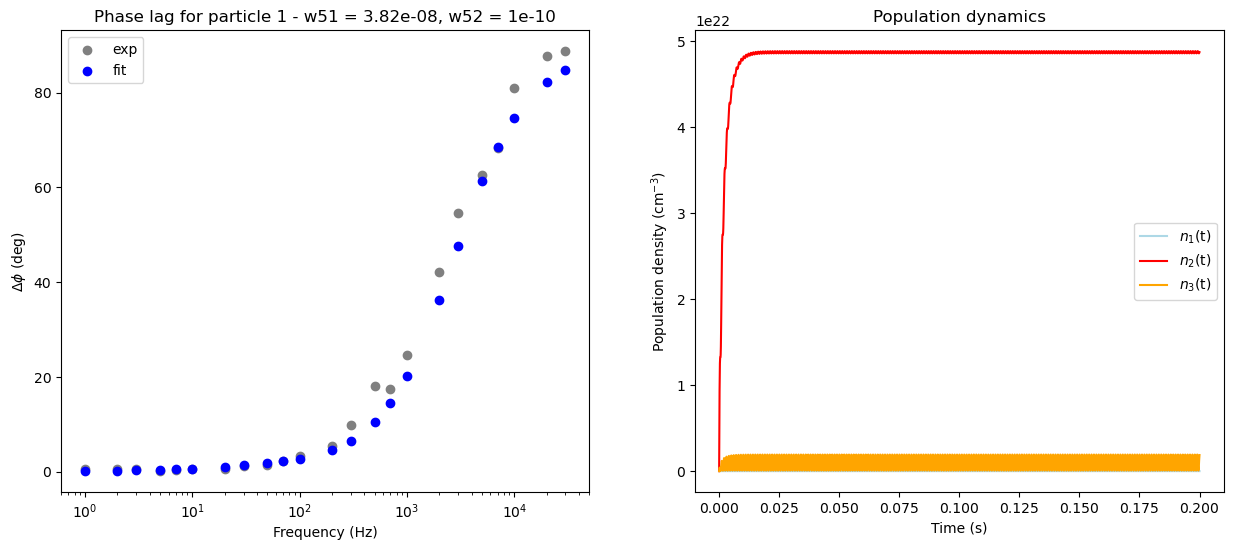

3.82e-08 1e-10
chute inicial = 1e-14, custo = 0.04162


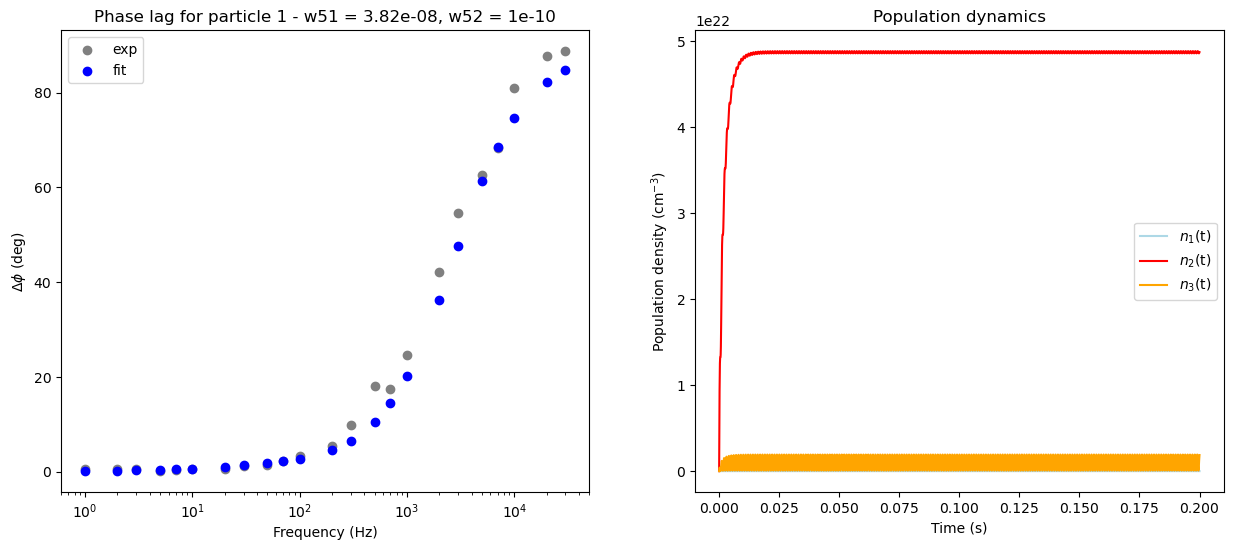

3.82e-08 1e-10
chute inicial = 1e-15, custo = 0.04162


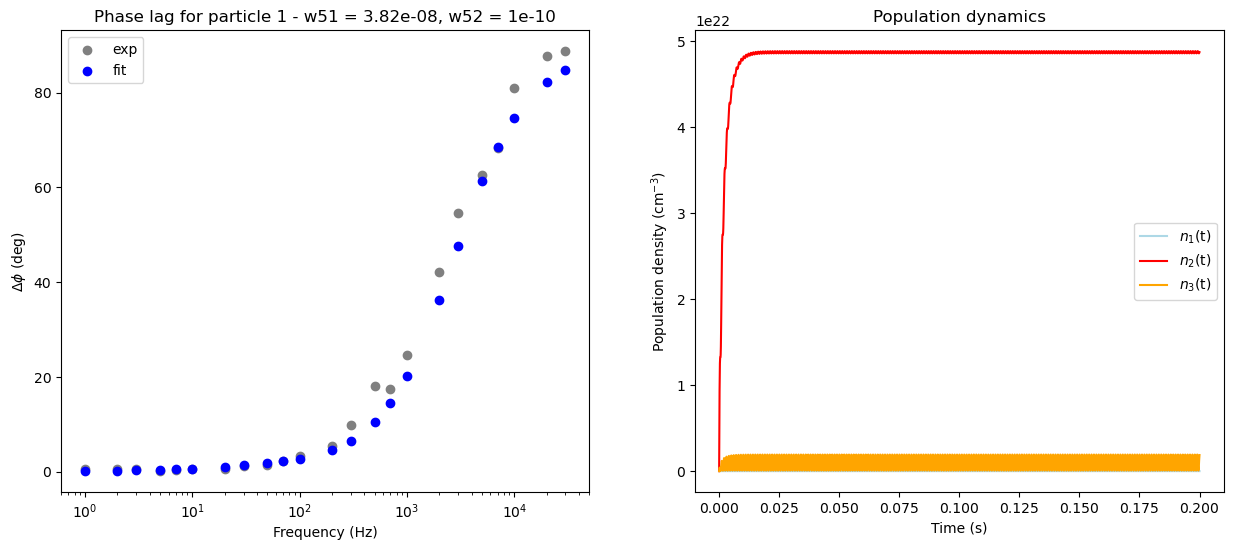

3.82e-08 1e-10
chute inicial = 1e-16, custo = 0.04162


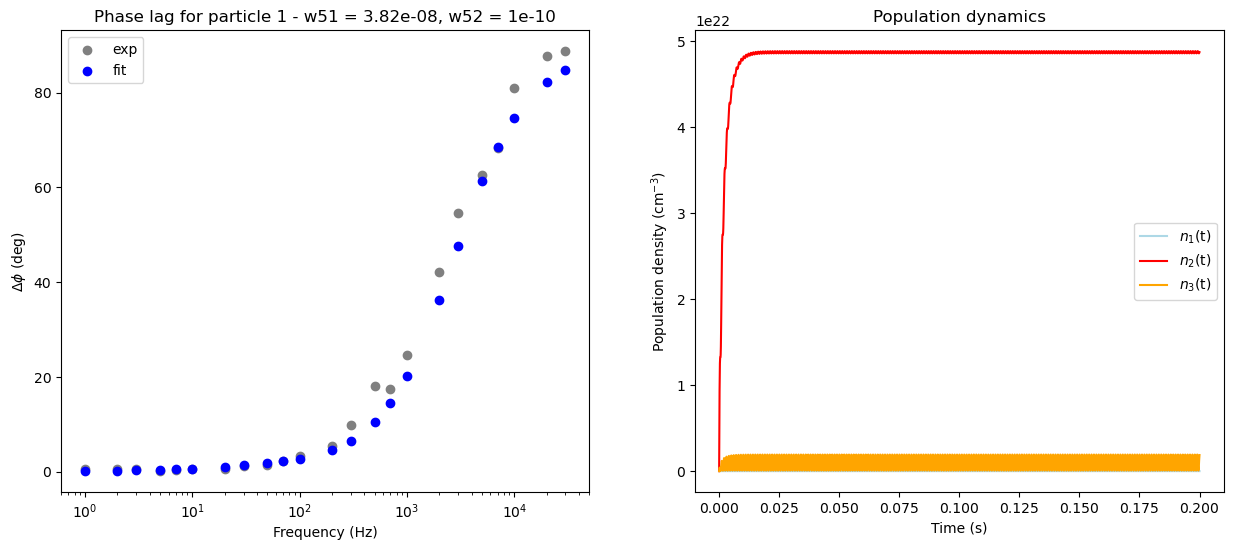

3.82e-08 1e-10
chute inicial = 1e-17, custo = 0.04162


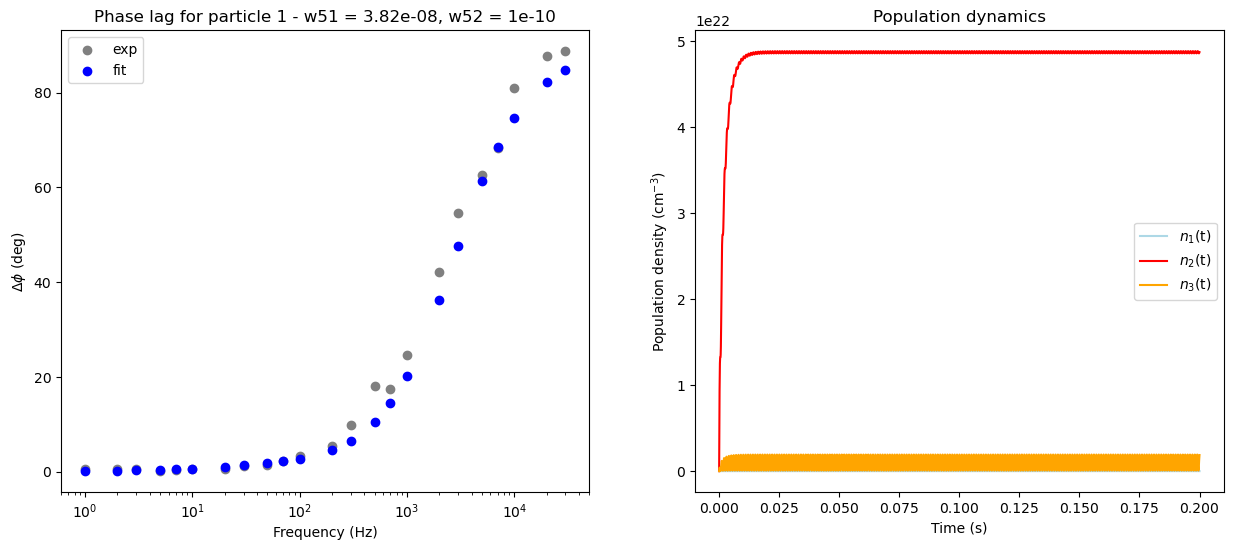

3.82e-08 1e-10
chute inicial = 1e-18, custo = 0.04162


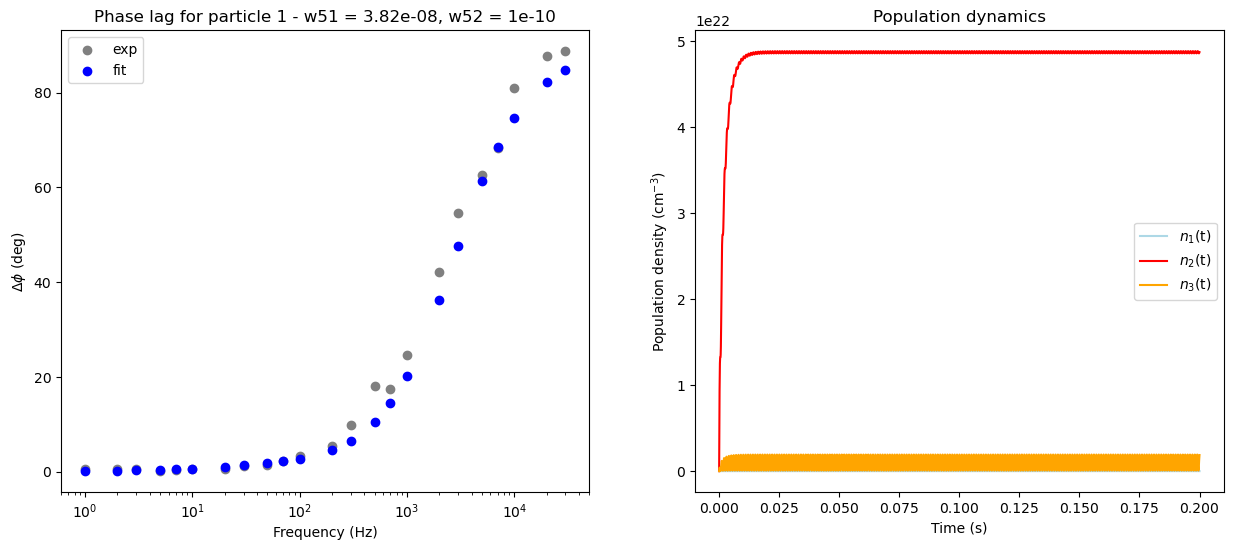

3.82e-08 1e-10
chute inicial = 1e-19, custo = 0.04162


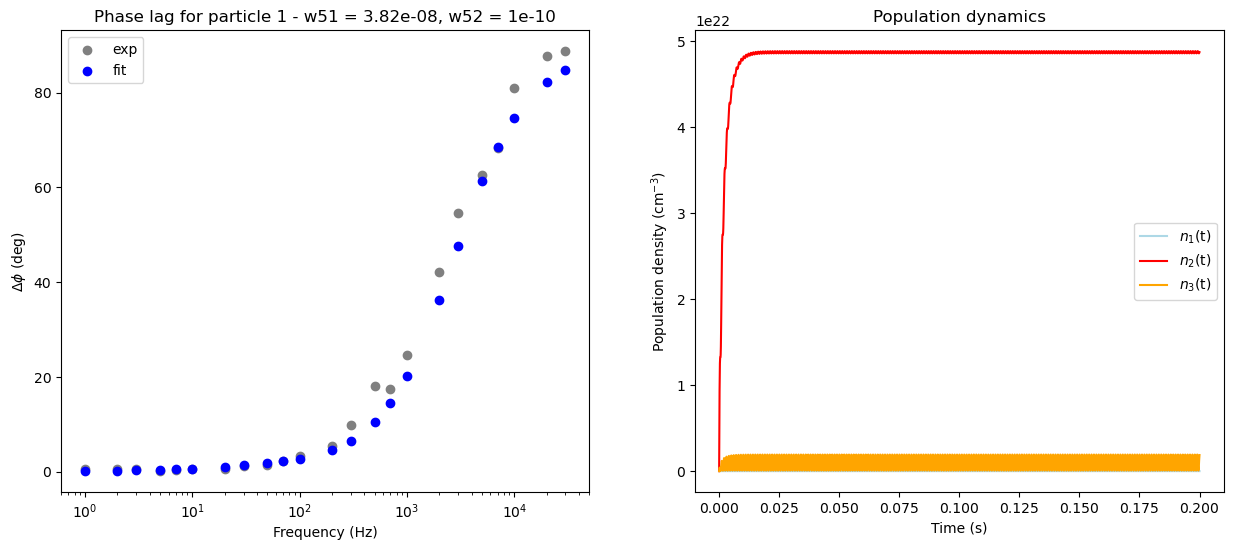

3.82e-08 1e-10
chute inicial = 1e-20, custo = 0.04162


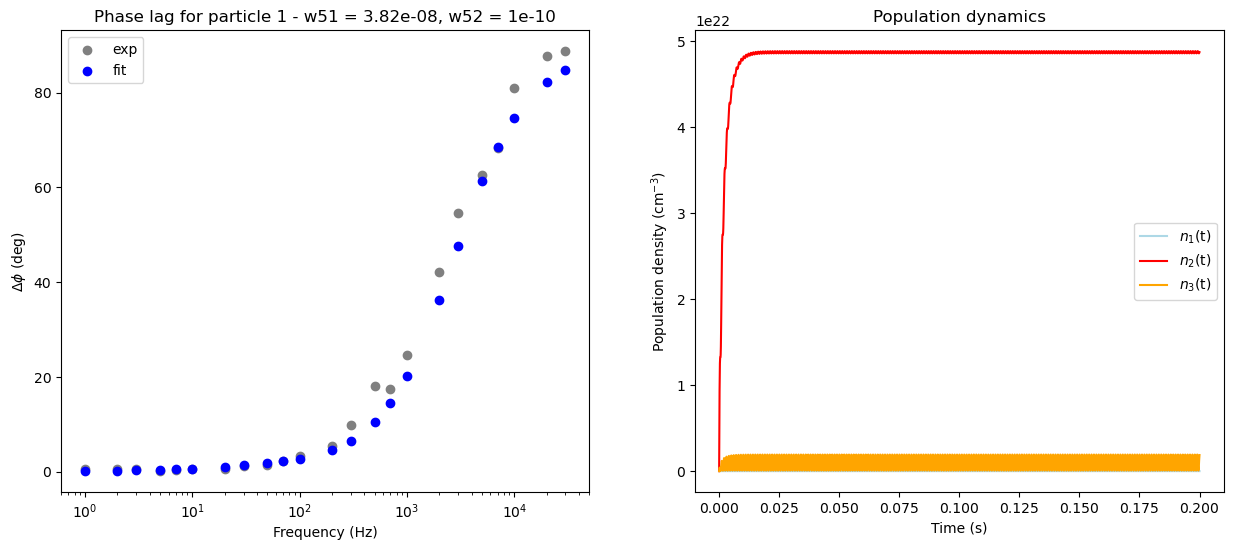

3.82e-08 1e-10
chute inicial = 1e-21, custo = 0.04162


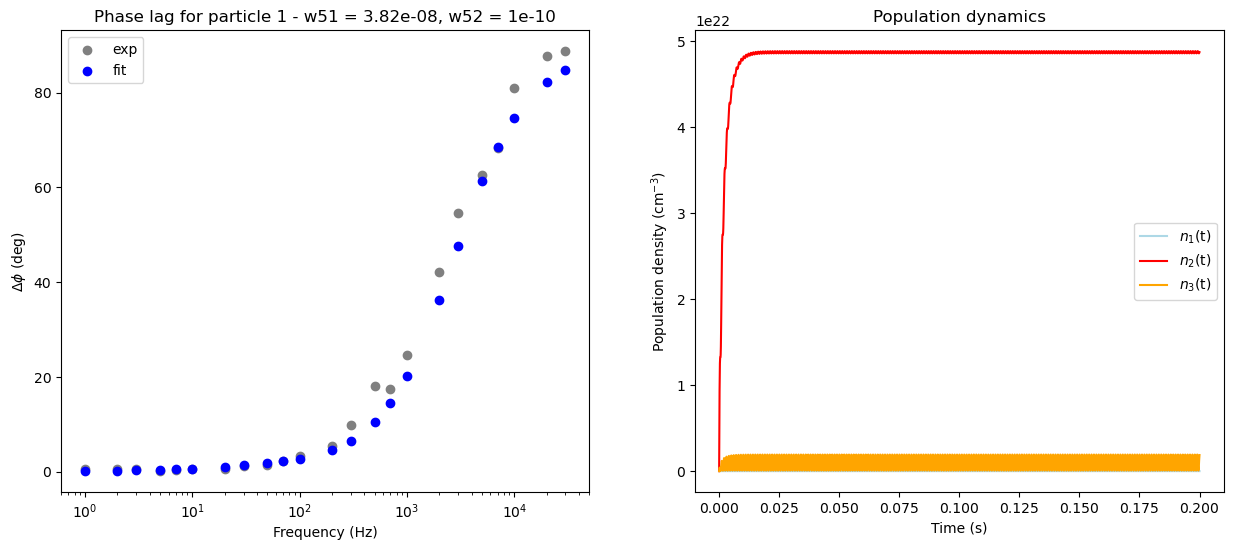

In [28]:
# W51, W52 = 9.61e-8, 2.5e-10

# num_points = 20 


for iv_idx, iv in enumerate(init_val_res):

    fases_calculadas = []
    print(iv[1], iv[2])

    for p_id, pd in enumerate(pd_list):
        if p_id != 0: continue
        frequencias_experimentais = pd[:num_points, 0] 
        fases_experimentais = pd[:num_points, 1] 

        W51, W52 = iv[1], iv[2]

        sol_to_plot = []
        
        for f in frequencias_experimentais:
            # Simula 200 ciclos em tempo adimensional para garantir que o transiente morra
            t_span = (0, 200) 
            t_eval = np.linspace(t_span[0], t_span[1], 10000)

            sol = solve_ivp(
            odes, 
            t_span, 
            [0, 0, 0], 
            t_eval=t_eval,
            args=(W51, W52, f), 
            method='Radau' # Mantendo o método Radau que demonstrou estabilidade acima
            )

            # Converte de volta para unidades físicas antes de extrair a fase
            n3 = (sol.y[2]) * n1 
            ts = (sol.t) * (1/f)

            n2 = (sol.y[1]) * n1 
            n11 = (sol.y[0]) * n1 

            if f == 1000:
                sol_to_plot = [ts, n11, n2, n3]

            # plt.plt(ts, n11)

            fase_calc = extrair_fase(ts, n3, f)
            fases_calculadas.append(fase_calc)

        fases_calculadas = np.array(fases_calculadas)

        print(f"chute inicial = {iv[0]}, custo = {iv[3]}")
        
        fig, axs = plt.subplots(1, 2, figsize=(15, 6))

        #Phase lag plot
        axs[0].scatter(frequencias_experimentais, adj_ph(fases_experimentais), color="gray", label="exp")
        axs[0].scatter(frequencias_experimentais, adj_ph(fases_calculadas), color="blue", label="fit")
        axs[0].set_xscale("log")
        axs[0].set_ylabel("$\Delta \phi$ (deg)")
        axs[0].set_xlabel("Frequency (Hz)")
        axs[0].set_title(f"Phase lag for particle 1 - w51 = {W51:.3}, w52 = {W52:.3}")
        axs[0].legend()

        #Population time evolution @ 1kHz
        
        ts, n11, n2, n3 = sol_to_plot

        axs[1].plot(ts, n11, color="lightblue", label="$n_1$(t)")
        axs[1].plot(ts, n2, color="red", label="$n_2$(t)")
        axs[1].plot(ts, n3, color="orange", label="$n_3$(t)")
        # axs[1].set_xscale("log")
        axs[1].set_ylabel("Population density (cm$^{-3}$)")
        axs[1].set_xlabel("Time (s)")
        axs[1].set_title(f"Population dynamics")
        axs[1].legend()

        plt.show()


In [ ]:
power = 4.6 # em W
w0 = (282e-9)*(1e2) # em cm
area = np.pi*w0**2
photon_energy = (6.62e-34*2.99e8)/977e-9

print(f"{(power/area):.2f}")

In [ ]:
np.log10(1841237206.94)

In [ ]:

# data.shape
ratio_list = [el[1]/el[2] for el in data]

plt.scatter(data[:,0], data[:,3], color="blue")
# plt.scatter(data[:,0], ratio_list, color="red")
plt.xscale("log")
plt.show()